# BERT Fine-Tuning 

In [ ]:
import os
# Force the environment to ignore the check before imports
os.environ["TRANSFORMERS_SAFE_MODE"] = "0" 
os.environ["TRANSFORMERS_NO_ADVISORY_WARNINGS"] = "1"

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 1. GPU Check
if torch.cuda.is_available():
    device = "cuda"
    gpu_name = torch.cuda.get_device_name(0)
    print(f"Using device: {device} ({gpu_name})")
else:
    device = "cpu"
    print(f"Using device: {device}")


# 2. Data Loading & Preprocessing
def load_data(file_path):
    data = []
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"Dataset not found at {file_path}. Please check your Kaggle input attachments.")
    with open(file_path, 'r', encoding='latin-1') as f:
        for line in f:
            if '@' in line:
                text, label = line.rsplit('@', 1)
                data.append([text.strip(), label.strip()])
    return pd.DataFrame(data, columns=['text', 'label'])

# Verified Kaggle Input path
dataset_path = ["/kaggle/input/datasets/ell1173/financial-phrasebank/Sentences_75Agree.txt",
                "/kaggle/input/datasets/ell1173/financial-phrasebank/Sentences_AllAgree.txt"]

df_75 = load_data(dataset_path[0])
df_all = load_data(dataset_path[1])

print(f"Sentences_75Agree rows: {len(df_75)}")
print(f"Sentences_AllAgree rows: {len(df_all)}")

combined = pd.concat([df_75, df_all], ignore_index=True)
n_duplicates = combined.duplicated(subset=['text']).sum()
print(f"Overlapping (duplicate) rows between the two files: {n_duplicates}")

df = combined.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"Final unique rows after combining both files: {len(df)}")

df['text'] = df['text'].str.lower().replace(r"http\S+|@\w+|\s+", " ", regex=True)

label_map = {"positive": 2, "neutral": 1, "negative": 0}
df['label'] = df['label'].map(label_map)

# 3. Split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)

# 4. Tokenization 
model_repo_id = "bert-base-uncased"  # Clean, generic English base model
tokenizer = AutoTokenizer.from_pretrained(model_repo_id)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

# 5. Dataset Class
class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

train_dataset = SentimentDataset(train_encodings, train_labels)
val_dataset = SentimentDataset(val_encodings, val_labels)

# 6. Load Model (GOOGLE BASE BERT)
model = AutoModelForSequenceClassification.from_pretrained(model_repo_id, num_labels=3)
model.to(device) 

# 7. Training Arguments
training_args = TrainingArguments(
    output_dir='/kaggle/working/results', 
    learning_rate=2e-5,
    per_device_train_batch_size=32, 
    per_device_eval_batch_size=32,
    num_train_epochs=4,
    warmup_steps=0.1,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    logging_strategy="epoch",  
    logging_steps=1,
    fp16=True, 
    load_best_model_at_end=True,
    report_to="none" 
)

def compute_metrics(pred):
    logits, labels = pred
    predictions = logits.argmax(axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    acc = accuracy_score(labels, predictions)
    return {'accuracy': acc, 'f1': f1, 'precision': precision, 'recall': recall}

# 8. Train
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

print("\n" + "="*40)
print("TRAINING VS VALIDATION LOSS PER EPOCH")
print("="*40)

history = trainer.state.log_history
epochs_data = {}

for log in history:
    epoch = log.get("epoch")
    if epoch is not None:
        epoch = round(epoch)
        if epoch not in epochs_data:
            epochs_data[epoch] = {"train_loss": "N/A", "val_loss": "N/A", "val_acc": "N/A"}
        
        if "loss" in log:
            epochs_data[epoch]["train_loss"] = round(log["loss"], 4)
        if "eval_loss" in log:
            epochs_data[epoch]["val_loss"] = round(log["eval_loss"], 4)
            epochs_data[epoch]["val_acc"] = round(log["eval_accuracy"], 4)

for epoch, metrics in epochs_data.items():
    print(f"Epoch {epoch}: Train Loss = {metrics['train_loss']} | Val Loss = {metrics['val_loss']} | Val Accuracy = {metrics['val_acc']}")
print("="*40 + "\n")

# 9. Save final version to Kaggle Working Directory
output_folder = "/kaggle/working/bert_finetuned_gpu"
model.save_pretrained(output_folder)
tokenizer.save_pretrained(output_folder)
print(f"Model and Tokenizer successfully saved to {output_folder}")

Using device: cuda (Tesla T4)
Sentences_75Agree rows: 3453
Sentences_AllAgree rows: 2264
Overlapping (duplicate) rows between the two files: 2269
Final unique rows after combining both files: 3448


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


TRAINING VS VALIDATION LOSS PER EPOCH
Epoch 1: Train Loss = 1.7781 | Val Loss = 1.1026 | Val Accuracy = 0.771
Epoch 2: Train Loss = 0.8575 | Val Loss = 0.5592 | Val Accuracy = 0.9174
Epoch 3: Train Loss = 0.4181 | Val Loss = 0.4878 | Val Accuracy = 0.9261
Epoch 4: Train Loss = 0.2622 | Val Loss = 0.441 | Val Accuracy = 0.929



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and Tokenizer successfully saved to /kaggle/working/bert_finetuned_gpu


# Evaluating Fine-Tuned BERT Model via Sentiment Inference Validation

In [6]:
from transformers import pipeline

# 1. Loading fine-tuned BERT model from the Kaggle output folder
model_path = "/kaggle/working/bert_finetuned_gpu"
classifier = pipeline("text-classification", model=model_path, tokenizer=model_path, device=0)

# 2. Curated real-world financial news examples with complex domain-specific vocabulary
examples = [
    {
        "text": "Nvidia shares surged 6% in premarket trading after crushing Wall Street revenue expectations and boosting its quarterly dividend.",
        "actual": "positive"
    },
    {
        "text": "The company's operating margin narrowed significantly due to rising supply chain bottlenecks and ballooning raw material costs.",
        "actual": "negative"
    },
    {
        "text": "The Federal Reserve held interest rates steady at its policy meeting, matching consensus expectations among economists.",
        "actual": "neutral"
    },
    {
        "text": "Tesla's quarterly deliveries fell 8.5% year-over-year, marking its first annual decline since the global pandemic disruptions.",
        "actual": "negative"
    },
    {
        "text": "Microsoft announced a multi-billion dollar partnership to expand cloud computing infrastructure across the European market.",
        "actual": "positive"
    },
    {
        "text": "Shares of the pharmaceutical giant tumbled following reports that the FDA rejected its new weight-loss drug candidate.",
        "actual": "negative"
    },
    {
        "text": "Apple is scheduled to report its third-quarter financial performance on Thursday after the market close.",
        "actual": "neutral"
    },
    {
        "text": "Retail sales rebounded sharply last month, indicating strong consumer spending resilience despite prolonged inflationary pressures.",
        "actual": "positive"
    },
    {
        "text": "The standard board meeting concluded without any decisions regarding corporate restructuring or executive leadership changes.",
        "actual": "neutral"
    },
    {
        "text": "Intel shares hit a fresh multi-year low as restructuring charges and server chip market share losses weighed on earnings.",
        "actual": "negative"
    },
    {
        "text": "Amazon launched its annual shopping holiday event across twenty countries, tracking in line with historical baseline volumes.",
        "actual": "neutral"
    },
    {
        "text": "The renewable energy startup secured $150 million in Series C funding to accelerate production scaling for its next-gen batteries.",
        "actual": "positive"
    }
]

# 3. Label index converter (Maps your index IDs back to text labels)
id2label = {0: "negative", 1: "neutral", 2: "positive"}

# 4. Execute Inference and Compare
print(f"{'NEWS HEADLINE':<90} | {'ACTUAL':<10} | {'PREDICTED (CONFIDENCE)':<22}")
print("-" * 130)

for item in examples:
    # Get model prediction
    prediction = classifier(item["text"])[0]
    
    # Extract index from label string (e.g., 'LABEL_2' -> 2)
    label_id = int(prediction["label"].split("_")[-1])
    predicted_sentiment = id2label[label_id]
    confidence = prediction["score"] * 100
    
    # Highlight mismatches if any occur
    mismatch_flag = "❌ MISMATCH" if predicted_sentiment != item["actual"] else "✅ MATCH"
    
    # Shorten text for neat printing structure
    short_text = item["text"][:87] + "..." if len(item["text"]) > 87 else item["text"]
    
    print(f"{short_text:<90} | {item['actual']:<10} | {predicted_sentiment} ({confidence:.1f}%) {mismatch_flag}")


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

NEWS HEADLINE                                                                              | ACTUAL     | PREDICTED (CONFIDENCE)
----------------------------------------------------------------------------------------------------------------------------------
Nvidia shares surged 6% in premarket trading after crushing Wall Street revenue expecta... | positive   | positive (98.2%) ✅ MATCH
The company's operating margin narrowed significantly due to rising supply chain bottle... | negative   | negative (94.4%) ✅ MATCH
The Federal Reserve held interest rates steady at its policy meeting, matching consensu... | neutral    | positive (98.1%) ❌ MISMATCH
Tesla's quarterly deliveries fell 8.5% year-over-year, marking its first annual decline... | negative   | negative (97.1%) ✅ MATCH
Microsoft announced a multi-billion dollar partnership to expand cloud computing infras... | positive   | positive (96.9%) ✅ MATCH
Shares of the pharmaceutical giant tumbled following reports that the FDA rejected

# Sentiment Score Aggregation

In [10]:
import os
import gc
import torch
import pandas as pd
from tqdm import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
os.environ["TOKENIZERS_PARALLELISM"] = "true"

# CONFIG
MODEL_PATH = "/kaggle/working/bert_finetuned_gpu"

DATASET_FILES = [
    "/kaggle/input/datasets/adityaraj73/tweets-datasets/Merged_Company_Tweets (2015-20).csv",
    "/kaggle/input/datasets/adityaraj73/tweets-datasets/Company_Tweets (2021-22).csv",
    "/kaggle/input/datasets/adityaraj73/tweets-datasets/stock-market-tweets-data (2020).csv"
]

CACHE_DIR = "/kaggle/working/sentiment_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

CHUNK_SIZE = 200000
BATCH_SIZE = 4096
MAX_LENGTH = 64

# LOAD MODEL
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("DEVICE:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("=" * 60)

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)
model = torch.nn.DataParallel(model)
model.to(device)
model.eval()

print("✓ Model loaded")

# SENTIMENT INFERENCE
def process_file(file_path):
    file_name = os.path.splitext(
        os.path.basename(file_path)
    )[0]
    print(f"\n{'='*70}")
    print(f"PROCESSING: {file_name}")
    print(f"{'='*70}")

    df = pd.read_csv(file_path)
    df["Date"] = pd.to_datetime(df["Date"]).dt.date
    tweets = df["Tweet"].astype(str).tolist()
    total_rows = len(tweets)
    print(f"Total Tweets: {total_rows:,}")
    sentiment_scores = []

    for start_idx in range(0, total_rows, CHUNK_SIZE):
        end_idx = min(start_idx + CHUNK_SIZE, total_rows)
        cache_file = os.path.join(
            CACHE_DIR,
            f"{file_name}_{start_idx}_{end_idx}.parquet"
        )

        # Resume support
        if os.path.exists(cache_file):
            print(
                f"Skipping chunk {start_idx:,}-{end_idx:,} (already completed)"
            )
            cached = pd.read_parquet(cache_file)
            sentiment_scores.extend(
                cached["sentiment_score"].tolist()
            )
            continue

        print(
            f"\nChunk: {start_idx:,} -> {end_idx:,}"
        )
        chunk_tweets = tweets[start_idx:end_idx]
        encodings = tokenizer(
            chunk_tweets,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )
        input_ids = encodings["input_ids"]
        attention_mask = encodings["attention_mask"]
        chunk_scores = []

        with torch.no_grad(), torch.amp.autocast("cuda"):

            for batch_start in tqdm(
                range(0, len(input_ids), BATCH_SIZE)
            ):

                batch_ids = input_ids[
                    batch_start:batch_start + BATCH_SIZE
                ].to(device)

                batch_mask = attention_mask[
                    batch_start:batch_start + BATCH_SIZE
                ].to(device)

                outputs = model(
                    input_ids=batch_ids,
                    attention_mask=batch_mask
                )
                probs = torch.softmax(
                    outputs.logits,
                    dim=-1
                )
                # positive - negative
                scores = (
                    probs[:, 2] - probs[:, 0]
                )
                chunk_scores.extend(
                    scores.cpu().numpy().tolist()
                )

        # Save chunk checkpoint
        pd.DataFrame({
            "sentiment_score": chunk_scores
        }).to_parquet(
            cache_file,
            index=False
        )
        sentiment_scores.extend(chunk_scores)
        del encodings
        del input_ids
        del attention_mask
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        print(
            f"Saved checkpoint: {os.path.basename(cache_file)}"
        )

    # Attach scores
    df["sentiment_score"] = sentiment_scores
    print("\nCreating Daily Aggregation...")
    daily_sentiment = (
        df.groupby(
            ["Date", "Stock Name"]
        )["sentiment_score"]
        .mean()
        .reset_index()
    )
    output_file = os.path.join(
        CACHE_DIR,
        f"{file_name}_daily_sentiment.parquet"
    )
    daily_sentiment.to_parquet(
        output_file,
        index=False
    )
    print(
        f"Saved daily sentiment: {output_file}"
    )
    return daily_sentiment

# MAIN
all_daily_data = []

for file_path in DATASET_FILES:
    if not os.path.exists(file_path):
        print(
            f"File not found: {file_path}"
        )
        continue
    result = process_file(file_path)
    all_daily_data.append(result)

# FINAL MASTER FILE
if len(all_daily_data) > 0:

    master_df = pd.concat(
        all_daily_data,
        ignore_index=True
    )
    master_df = master_df.sort_values(
        by="Date"
    )
    output_file = (
        "/kaggle/working/master_sentiment_features.csv"
    )
    master_df.to_csv(
        output_file,
        index=False
    )
    print("\n" + "="*70)
    print("SUCCESS")
    print("="*70)
    print(f"Master file saved:")
    print(output_file)
    print(f"Rows: {len(master_df):,}")

else:
    print("No files processed.")

DEVICE: Tesla T4


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✓ Model loaded

PROCESSING: Merged_Company_Tweets (2015-20)
Total Tweets: 4,336,445

Chunk: 0 -> 200,000


100%|██████████| 49/49 [01:34<00:00,  1.93s/it]


Saved checkpoint: Merged_Company_Tweets (2015-20)_0_200000.parquet

Chunk: 200,000 -> 400,000


...

Saved checkpoint: stock-market-tweets-data (2020)_200000_400000.parquet

Chunk: 400,000 -> 600,000


100%|██████████| 49/49 [01:35<00:00,  1.95s/it]


Saved checkpoint: stock-market-tweets-data (2020)_400000_600000.parquet

Chunk: 600,000 -> 626,932


100%|██████████| 7/7 [00:12<00:00,  1.81s/it]


Saved checkpoint: stock-market-tweets-data (2020)_600000_626932.parquet

Creating Daily Aggregation...
Saved daily sentiment: /kaggle/working/sentiment_cache/stock-market-tweets-data (2020)_daily_sentiment.parquet

SUCCESS
Master file saved:
/kaggle/working/master_sentiment_features.csv
Rows: 105,702


# Merge Stock & Sentiment Score

In [ ]:
import os
import yfinance as yf
import pandas as pd
import time
import random
import pickle
from tqdm import tqdm

SENTIMENT_FILE_PATH = '/kaggle/input/datasets/ell1173/final-dataset2/master_sentiment_features.csv'
OUTPUT_FILE_PATH    = '/kaggle/working/final_prediction_dataset.csv'
CACHE_FILE          = '/kaggle/working/price_cache.pkl'

# ── 1. Load & clean sentiment ──────────────────────────────────────────────
sentiment_df = pd.read_csv(SENTIMENT_FILE_PATH)
sentiment_df['Date'] = pd.to_datetime(sentiment_df['Date']).dt.strftime('%Y-%m-%d')
sentiment_df['Stock Name'] = (
    sentiment_df['Stock Name']
    .str.replace('$', '', regex=False)
    .str.upper().str.strip()
)

start_date = sentiment_df['Date'].min()
end_date   = sentiment_df['Date'].max()

# ── 2. Filter noise tickers ────────────────────────────────────────────────
CURRENCIES = {'USD','EUR','GBP','JPY','CAD','AUD','CHF','NZD','SEK','NOK',
              'DKK','SGD','HKD','CNH','INR','BRL','MXN','ZAR','TRY','RUB'}
SKIP_EXACT = {
    'BITCOIN','ETHEREUM','CRYPTO','DOGE','BLOCKCHAIN',
    'CORONAVIRUS','PANDEMIC','RANDOM','TRUMP','AMAZON','GOOGLE',
    'FACEBOOK','APPLE','TESLA','DISNEY','NETFLIX','CISCO','NIKE',
    'FORD','DELTA','UNITED','HERTZ','MARKET','TRADE','INVEST',
    'STOCK','BANK','FUND','FATANG','FAANG','FAAMG','FANGAM',
    'FATMANG','FANGMAN','NYSE','NASDAQ','NYSEARCA','NYSEAMERICAN',
    'OTCQB','DJIA','GSPC','IXIC','DJI','NIFTY','FTSE','DAX','NIKKEI',
    'VIX','VVIX','SPX','NDX','RUT','COMPQ','COMPQX','NASDA',
}

def is_valid_ticker(t):
    if not t.isalpha() or not (1 <= len(t) <= 5):
        return False
    if t in SKIP_EXACT:
        return False
    if len(t) == 6 and t[:3] in CURRENCIES and t[3:] in CURRENCIES:
        return False
    return True

all_tickers   = sentiment_df['Stock Name'].unique().tolist()
valid_tickers = [t for t in all_tickers if is_valid_ticker(t)]
print(f"Valid tickers to fetch: {len(valid_tickers)} / {len(all_tickers)}")

# ── 3. Load cache ────────────────────────────────────────────────────────
def load_cache(path):
    if not os.path.exists(path):
        return {'success': {}, 'failed': set()}
    try:
        with open(path, 'rb') as f:
            data = pickle.load(f)
        print(f"Resuming: {len(data['success'])} fetched, {len(data['failed'])} failed")
        return data
    except (EOFError, pickle.UnpicklingError, Exception) as e:
        print(f"Cache corrupted ({e}), checking backup...")
        backup = path + '.bak'
        if os.path.exists(backup):
            try:
                with open(backup, 'rb') as f:
                    data = pickle.load(f)
                print(f"Loaded backup: {len(data['success'])} fetched, {len(data['failed'])} failed")
                return data
            except Exception as e2:
                print(f"Backup also corrupted ({e2}), starting fresh.")
        else:
            print("No backup found, starting fresh.")
        return {'success': {}, 'failed': set()}

def save_cache(cache, path):
    """Write to temp file first, then replace — prevents corruption on crash."""
    tmp = path + '.tmp'
    bak = path + '.bak'
    with open(tmp, 'wb') as f:
        pickle.dump(cache, f)
    if os.path.exists(path):
        if os.path.exists(bak):
            os.remove(bak)
        os.rename(path, bak)
    os.rename(tmp, path)

cache = load_cache(CACHE_FILE)

# ── 4. Build todo list (THIS WAS MISSING) ──────────────────────────────────
todo = [t for t in valid_tickers if t not in cache['success'] and t not in cache['failed']]
print(f"Remaining to fetch: {len(todo)}")

# ── 5. Fetch one ticker at a time ──────────────────────────────────────────
consecutive_rate_limits = 0

def fetch_one(ticker, start, end, max_retries=7):
    global consecutive_rate_limits
    delay = 10
    rate_limited = False

    for attempt in range(max_retries):
        try:
            df = yf.download(ticker, start=start, end=end,
                             auto_adjust=True, progress=False, threads=False,
                             timeout=10)
            if df.empty:
                consecutive_rate_limits = 0
                return None, False

            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)

            cols = [c for c in ['Open','High','Low','Close','Volume'] if c in df.columns]
            if 'Close' not in cols:
                consecutive_rate_limits = 0
                return None, False

            df = df[cols].dropna(how='all')
            if df.empty:
                consecutive_rate_limits = 0
                return None, False

            df.index = pd.to_datetime(df.index).strftime('%Y-%m-%d')
            df.index.name = 'Date'
            df = df.reset_index()
            df['Stock Name'] = ticker
            consecutive_rate_limits = 0
            return df, False

        except Exception as e:
            err = str(e).lower()
            if 'rate limit' in err or '429' in err or 'too many' in err:
                rate_limited = True
                consecutive_rate_limits += 1
                wait = delay + random.uniform(0, delay * 0.5)
                if consecutive_rate_limits >= 3:
                    long_break = 120 + random.uniform(0, 60)
                    print(f"\n⚠ {consecutive_rate_limits} consecutive rate limits. "
                          f"Cooling down for {long_break:.0f}s...")
                    time.sleep(long_break)
                    consecutive_rate_limits = 0
                else:
                    time.sleep(wait)
                delay = min(delay * 2, 180)
            elif 'timed out' in err or 'timeout' in err or 'resolving' in err:
                time.sleep(3 + random.uniform(0, 2))
                continue
            else:
                return None, False

    return None, rate_limited


SAVE_EVERY = 100
INTER_TICKER_DELAY = 3.0

for i, ticker in enumerate(tqdm(todo, desc="Fetching")):
    result, was_rate_limited = fetch_one(ticker, start_date, end_date)

    if result is not None:
        cache['success'][ticker] = result
    elif not was_rate_limited:
        cache['failed'].add(ticker)

    if (i + 1) % SAVE_EVERY == 0:
        save_cache(cache, CACHE_FILE)

    if consecutive_rate_limits > 0:
        time.sleep(INTER_TICKER_DELAY * 3 + random.uniform(0, 2))
    else:
        time.sleep(INTER_TICKER_DELAY + random.uniform(0, 1.5))

# Final save (uses safe save_cache, not raw pickle.dump)
save_cache(cache, CACHE_FILE)

print(f"\nDone. Fetched: {len(cache['success'])}  |  Failed: {len(cache['failed'])}")

# ── 6. Build price DataFrame ───────────────────────────────────────────────
price_df = pd.concat(cache['success'].values(), ignore_index=True)
price_df['Stock Name'] = price_df['Stock Name'].str.upper().str.strip()

# ── 7. Merge & engineer target ─────────────────────────────────────────────
print("\nMerging...")
final_df = pd.merge(sentiment_df, price_df, on=['Date','Stock Name'], how='left')
final_df = final_df.sort_values(['Stock Name','Date']).reset_index(drop=True)

market_cols = ['Open','High','Low','Close','Volume']
final_df[market_cols] = final_df.groupby('Stock Name')[market_cols].ffill()
final_df.dropna(subset=['Close'], inplace=True)

final_df['Target_Next_Day_Close'] = final_df.groupby('Stock Name')['Close'].shift(-1)
final_df.dropna(subset=['Target_Next_Day_Close'], inplace=True)

# ── 8. Summary ─────────────────────────────────────────────────────────────
print(f"\n--- Final Summary ---")
print(f"Unique Tickers : {final_df['Stock Name'].nunique()}")
print(f"Total Rows     : {len(final_df)}")
print(f"Date Range     : {final_df['Date'].min()} → {final_df['Date'].max()}")

final_df.to_csv(OUTPUT_FILE_PATH, index=False)
print(f"Saved to: {OUTPUT_FILE_PATH}")

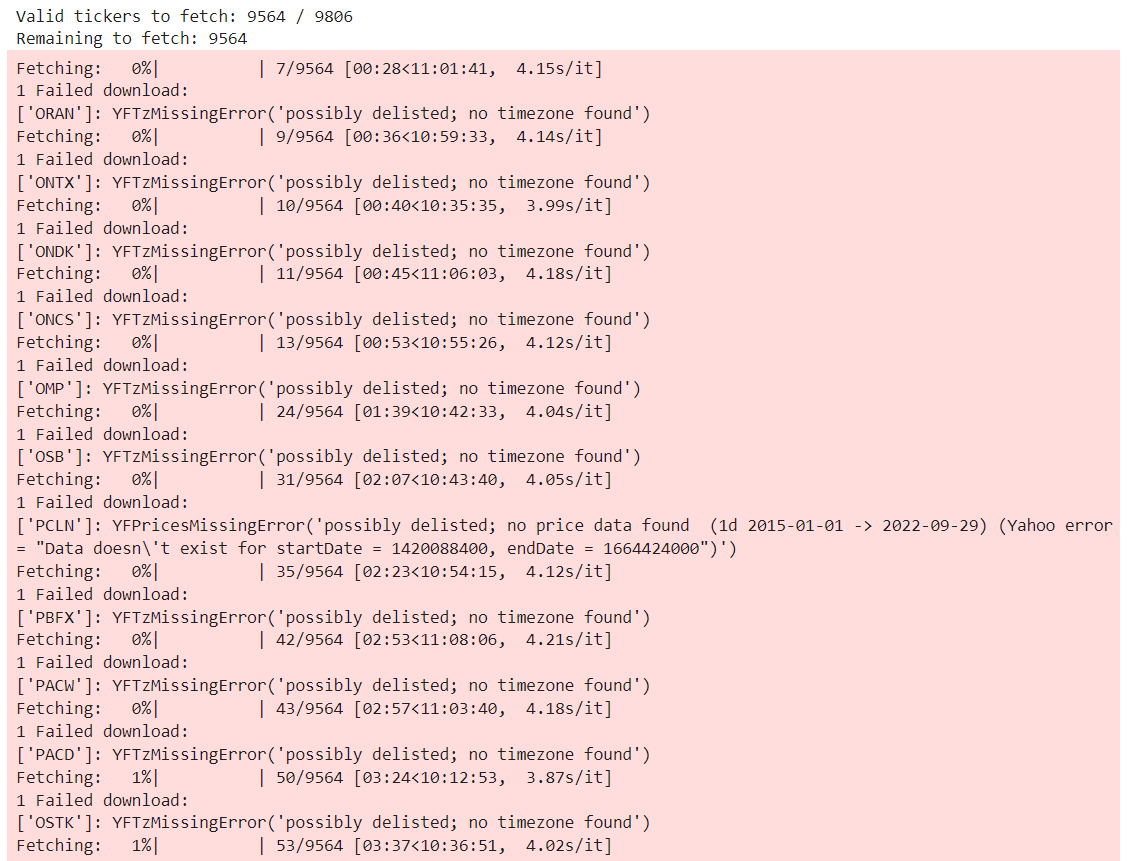

# XGBoost Classifier

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('Agg')   # Non-interactive backend — safe in Kaggle notebooks
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# ─────────────────────────────────────────────────────────────────────────────
# 0. KAGGLE PATHS
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH = '/kaggle/input/datasets/ell1173/final-dataset2/final_prediction_dataset.csv'
OUTPUT_DIR = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────────
# 1. GPU DETECTION
# ─────────────────────────────────────────────────────────────────────────────
try:
    import subprocess
    gpu_check = subprocess.run(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'],
                               capture_output=True, text=True, timeout=5)
    if gpu_check.returncode == 0 and gpu_check.stdout.strip():
        DEVICE = 'cuda'
        GPU_NAME = gpu_check.stdout.strip().split('\n')[0]
        print(f"GPU detected: {GPU_NAME}  →  Using CUDA")
    else:
        DEVICE = 'cpu'
        print("No GPU detected  →  Using CPU (training will be slower)")
except Exception:
    DEVICE = 'cpu'
    print("GPU check failed  →  Defaulting to CPU")

# ─────────────────────────────────────────────────────────────────────────────
# 2. LOAD DATA
# ─────────────────────────────────────────────────────────────────────────────
print(f"\nLoading data from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

def parse_dates_robust(series):
    for fmt in ('%Y-%m-%d', '%d-%m-%Y', '%m/%d/%Y', '%d/%m/%Y'):
        try:
            return pd.to_datetime(series, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.to_datetime(series, format='mixed', dayfirst=True)

df['Date'] = parse_dates_robust(df['Date'])
df = df.sort_values(['Stock Name', 'Date']).reset_index(drop=True)

print(f"  Rows loaded      : {len(df):,}")
print(f"  Unique tickers   : {df['Stock Name'].nunique():,}")
print(f"  Date range       : {df['Date'].min().date()} → {df['Date'].max().date()}")

# ─────────────────────────────────────────────────────────────────────────────
# 3. FIX #1 — REMOVE FORWARD-FILLED / STALE ROWS
#    Many "consecutive" calendar dates are actually weekends/holidays where the
#    OHLCV values were forward-filled from the last real trading day (identical
#    Open/High/Low/Close/Volume to the row before). These aren't real
#    observations — left in, they inject fake "zero movement" days into
#    returns/RSI/volatility. We drop any row that exactly repeats the prior
#    row's OHLCV for the same ticker.
# ─────────────────────────────────────────────────────────────────────────────
print("\nRemoving forward-filled / stale (non-trading-day) rows...")
OHLCV_COLS = ['Open', 'High', 'Low', 'Close', 'Volume']
prev_ohlcv = df.groupby('Stock Name')[OHLCV_COLS].shift(1)
is_stale = (df[OHLCV_COLS] == prev_ohlcv).all(axis=1)
print(f"  Stale rows removed: {int(is_stale.sum()):,} / {len(df):,}")
df = df[~is_stale].copy().reset_index(drop=True)
print(f"  Rows remaining    : {len(df):,}")

# ─────────────────────────────────────────────────────────────────────────────
# 4. FIX #2 — MINIMUM-HISTORY FILTER PER TICKER
#    14-day / 7-day rolling features are meaningless (all-NaN) for tickers with
#    too little history, and used to vanish silently via a blanket dropna()
#    later in the pipeline. We filter them out explicitly here, with a printed
#    count, so the data loss is visible rather than hidden.
# ─────────────────────────────────────────────────────────────────────────────
MIN_ROWS_PER_TICKER = 20
print(f"\nFiltering tickers with fewer than {MIN_ROWS_PER_TICKER} rows...")
ticker_counts = df['Stock Name'].value_counts()
valid_tickers = ticker_counts[ticker_counts >= MIN_ROWS_PER_TICKER].index
n_dropped_tickers = df['Stock Name'].nunique() - len(valid_tickers)
rows_before = len(df)
df = df[df['Stock Name'].isin(valid_tickers)].copy().reset_index(drop=True)
print(f"  Tickers dropped   : {n_dropped_tickers:,} / {ticker_counts.size:,}")
print(f"  Rows dropped      : {rows_before - len(df):,}")
print(f"  Rows remaining    : {len(df):,}  |  Tickers remaining: {df['Stock Name'].nunique():,}")

# ─────────────────────────────────────────────────────────────────────────────
# 5. FEATURE ENGINEERING
#    FIX #3 — all rolling windows below now use calendar-time windows (e.g.
#    '7D', '14D' via rolling(..., on='Date')) instead of row-count windows.
#    This matters because gaps in the data (4, 19, 44+ day jumps were found)
#    meant a "7-row" window used to silently span anywhere from a week to
#    several months depending on how sparse that stretch of data was.
#
#    FIX #4 — a new 'gap_days' feature records how many calendar days
#    elapsed since the ticker's previous observation, so the model can learn
#    to weigh a return/RSI value differently when it spans 1 day vs. 30 days,
#    rather than treating every row's features as equally "fresh".
# ─────────────────────────────────────────────────────────────────────────────
print("\nEngineering features (calendar-time aware)...")

df['gap_days'] = df.groupby('Stock Name')['Date'].diff().dt.days.fillna(0)

df['returns'] = df.groupby('Stock Name')['Close'].pct_change()

df['volatility'] = (
    df.groupby('Stock Name')
      .rolling('7D', on='Date', min_periods=2)['returns']
      .std()
      .values
)

def add_calendar_rsi(frame, period_days=14):
    """14-day RSI computed over a true calendar-time window per ticker."""
    delta = frame.groupby('Stock Name')['Close'].diff()
    frame['_gain'] = delta.where(delta > 0, 0.0)
    frame['_loss'] = (-delta.where(delta < 0, 0.0))
    avg_gain = (
        frame.groupby('Stock Name')
             .rolling(f'{period_days}D', on='Date', min_periods=2)['_gain']
             .mean().values
    )
    avg_loss = (
        frame.groupby('Stock Name')
             .rolling(f'{period_days}D', on='Date', min_periods=2)['_loss']
             .mean().values
    )
    frame['rsi'] = 100 - (100 / (1 + (avg_gain / (avg_loss + 1e-9))))
    frame.drop(columns=['_gain', '_loss'], inplace=True)
    return frame

df = add_calendar_rsi(df, period_days=14)

# Sentiment z-score (normalised against each stock's own 14-calendar-day baseline)
df['sent_ma_14'] = (
    df.groupby('Stock Name')
      .rolling('14D', on='Date', min_periods=2)['sentiment_score']
      .mean().values
)
df['sent_std_14'] = (
    df.groupby('Stock Name')
      .rolling('14D', on='Date', min_periods=2)['sentiment_score']
      .std().values
)
df['sent_zscore'] = (df['sentiment_score'] - df['sent_ma_14']) / (df['sent_std_14'] + 1e-9)

# Sentiment momentum (3-calendar-day MA)
df['sent_ma_3'] = (
    df.groupby('Stock Name')
      .rolling('3D', on='Date', min_periods=1)['sentiment_score']
      .mean().values
)

# ─────────────────────────────────────────────────────────────────────────────
# 6. NOISE FILTERING — keep only days with > 0.5% price move
# ─────────────────────────────────────────────────────────────────────────────
df['price_move_pct'] = (df['Target_Next_Day_Close'] - df['Close']) / df['Close']
rows_before = len(df)
df = df[df['price_move_pct'].abs() > 0.005].copy()
df['Target_Trend'] = (df['price_move_pct'] > 0).astype(int)
print(f"\nNoise filter (>0.5% move) removed: {rows_before - len(df):,} rows")

rows_before = len(df)
df.dropna(inplace=True)
print(f"dropna() removed                 : {rows_before - len(df):,} rows")
print(f"Final dataset                    : {len(df):,} rows  |  {df['Stock Name'].nunique():,} tickers")
print(f"Class balance  →  Up: {df['Target_Trend'].mean():.1%}  |  Down: {1 - df['Target_Trend'].mean():.1%}")

# ─────────────────────────────────────────────────────────────────────────────
# 7. FIX #5 — PER-TICKER TIME-BASED SPLIT
#    The original split sorted by ['Stock Name', 'Date'] then sliced by row
#    position. Because that sort is primarily alphabetical by ticker, the
#    85/15 cut mostly separated by COMPANY, not by TIME — verified that 476 of
#    477 test-set tickers never appeared in train at all. That tests
#    generalization to brand-new companies, not next-day forecasting for
#    companies the model has already learned from (which is what the
#    asymmetric-threshold trading logic below assumes).
#
#    Fix: split EACH ticker's own date-sorted rows 85/15, so every ticker
#    contributes both training history and a genuine future test period.
# ─────────────────────────────────────────────────────────────────────────────
df = df.sort_values(['Stock Name', 'Date']).reset_index(drop=True)

def per_ticker_time_split(frame, test_frac=0.15):
    train_idx, test_idx = [], []
    for _, g in frame.groupby('Stock Name', sort=False):
        n = len(g)
        cut = max(1, int(np.floor(n * (1 - test_frac))))
        cut = min(cut, n - 1) if n > 1 else n
        train_idx.append(g.index[:cut])
        test_idx.append(g.index[cut:])
    return np.concatenate(train_idx), np.concatenate(test_idx)

train_idx, test_idx = per_ticker_time_split(df, test_frac=0.15)

FEATURES = ['sent_zscore', 'sent_ma_3', 'returns', 'volatility', 'rsi', 'gap_days']
X_train, X_test = df.loc[train_idx, FEATURES], df.loc[test_idx, FEATURES]
y_train, y_test = df.loc[train_idx, 'Target_Trend'], df.loc[test_idx, 'Target_Trend']

train_stocks = set(df.loc[train_idx, 'Stock Name'])
test_stocks = set(df.loc[test_idx, 'Stock Name'])
print(f"\nTrain samples: {len(X_train):,}  |  Test samples: {len(X_test):,}")
print(f"Tickers in train: {len(train_stocks):,}  |  in test: {len(test_stocks):,}  "
      f"|  overlap: {len(train_stocks & test_stocks):,}")

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest  = xgb.DMatrix(X_test,  label=y_test)

# ─────────────────────────────────────────────────────────────────────────────
# 8. XGBOOST TRAINING
# ─────────────────────────────────────────────────────────────────────────────
print(f"\nTraining XGBoost on {DEVICE.upper()}...")

params = {
    'max_depth'        : 4,
    'eta'              : 0.015,
    'objective'        : 'binary:logistic',
    'tree_method'      : 'hist',
    'device'           : DEVICE,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'eval_metric'      : 'auc',
    'gamma'            : 1.5,
    'seed'             : 42,
}

model = xgb.train(
    params,
    dtrain,
    num_boost_round       = 2000,
    evals                 = [(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds = 100,
    verbose_eval          = 200,
)

print(f"\nBest iteration  : {model.best_iteration}")
print(f"Best test AUC   : {model.best_score:.4f}")

# ─────────────────────────────────────────────────────────────────────────────
# 9. ASYMMETRIC THRESHOLDING
# ─────────────────────────────────────────────────────────────────────────────
print("\nApplying asymmetric confidence thresholds...")
probs = model.predict(dtest)

y_pred = np.where(probs > 0.60, 1,
         np.where(probs < 0.48, 0, -1))

mask = y_pred != -1
abstain_pct = (~mask).mean() * 100
print(f"  Signals kept   : {mask.sum():,} / {len(y_test):,}  ({100 - abstain_pct:.1f}% coverage)")
print(f"  Abstained      : {(~mask).sum():,}  ({abstain_pct:.1f}% filtered as uncertain)")

# ─────────────────────────────────────────────────────────────────────────────
# 10. EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
if mask.sum() == 0:
    print("\nNo signals passed the confidence threshold — lower thresholds and retry.")
else:
    acc = accuracy_score(y_test[mask], y_pred[mask])
    print(f"\n{'='*55}")
    print(f"  High-Confidence Directional Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"{'='*55}")
    print(classification_report(y_test[mask], y_pred[mask],
                                 target_names=['Down (0)', 'Up (1)']))

    cm   = confusion_matrix(y_test[mask], y_pred[mask])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Down (0)', 'Up (1)'])

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap='Blues', values_format='d', ax=ax)
    ax.set_title(
        f'XGBoost Confusion Matrix\n'
        f'High-Confidence Predictions: {mask.sum():,} trades  |  Accuracy: {acc*100:.2f}%',
        pad=12
    )
    plt.tight_layout()
    cm_path = os.path.join(OUTPUT_DIR, 'confusion_matrix.png')
    plt.savefig(cm_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nConfusion matrix saved to: {cm_path}")

    fig2, ax2 = plt.subplots(figsize=(8, 5))
    xgb.plot_importance(model, ax=ax2, importance_type='gain',
                         title='Feature Importance (Gain)', max_num_features=10)
    plt.tight_layout()
    fi_path = os.path.join(OUTPUT_DIR, 'feature_importance.png')
    plt.savefig(fi_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Feature importance saved to: {fi_path}")

# ─────────────────────────────────────────────────────────────────────────────
# 11. SAVE MODEL
# ─────────────────────────────────────────────────────────────────────────────
model_path = os.path.join(OUTPUT_DIR, 'final_stock_model.json')
model.save_model(model_path)
print(f"\nModel saved to: {model_path}")
print("To reload:  model = xgb.Booster(); model.load_model('final_stock_model.json')")

GPU detected: Tesla T4  →  Using CUDA

Loading data from: /kaggle/input/datasets/ell1173/final-dataset2/final_prediction_dataset.csv
  Rows loaded      : 68,541
  Unique tickers   : 3,646
  Date range       : 2015-01-02 → 2022-09-28

Removing forward-filled / stale (non-trading-day) rows...
  Stale rows removed: 15,485 / 68,541
  Rows remaining    : 53,056

Filtering tickers with fewer than 20 rows...
  Tickers dropped   : 2,999 / 3,646
  Rows dropped      : 21,423
  Rows remaining    : 31,633  |  Tickers remaining: 647

Engineering features (calendar-time aware)...

Noise filter (>0.5% move) removed: 11,011 rows
dropna() removed                 : 1,956 rows
Final dataset                    : 18,666 rows  |  647 tickers
Class balance  →  Up: 54.0%  |  Down: 46.0%

Train samples: 15,557  |  Test samples: 3,109
Tickers in train: 647  |  in test: 647  |  overlap: 647

Training XGBoost on CUDA...
[0]	train-auc:0.53221	test-auc:0.52459
[138]	train-auc:0.63289	test-auc:0.52121

Best iteratio